## Importações

In [1]:
%matplotlib inline

import warnings

import matplotlib.pyplot as plt
import pandas as pd

from darts import TimeSeries, concatenate
from darts.dataprocessing.transformers import Scaler
from darts.models import TCNModel
from darts.utils.callbacks import TFMProgressBar
from darts.utils.timeseries_generation import datetime_attribute_timeseries


warnings.filterwarnings("ignore")

def generate_torch_kwargs():
    # run torch models on CPU, and disable progress bars for all model stages except training.
    return {
        "pl_trainer_kwargs": {
            "accelerator": "cpu",
            "callbacks": [TFMProgressBar(enable_train_bar_only=True)],
        }
    }

C:\Users\341789\OneDrive - eletrobras.com\Projetos\_dev\tcc-mateus-marques-pinto\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


## Carregamento de dados

In [2]:
dataframe_n_seco_diario = pd.read_csv("INTERCAMBIO_NORTE_SUDESTE-CENTRO-OESTE_DIARIO_2024-2025.csv", sep=";", encoding="utf-8")

dataframe_n_seco_diario["din_instante"] = pd.to_datetime(dataframe_n_seco_diario["din_instante"])

dataframe_n_seco_diario.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 670 entries, 0 to 669
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   din_instante            670 non-null    datetime64[ns]
 1   nom_subsistema_origem   670 non-null    object        
 2   nom_subsistema_destino  670 non-null    object        
 3   val_intercambiomwmed    670 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 21.1+ KB


## Carrega dataset

In [3]:
# Define dataset
range_train_val = pd.date_range(start="2024-01-01 00:00:00", end="2025-09-30 23:59:00", freq="D")
range_compare = pd.date_range(start="2025-10-01", end="2025-10-31", freq="D")

dataframe_n_seco_diario_set2025 = dataframe_n_seco_diario[dataframe_n_seco_diario['din_instante'].isin(range_train_val)]

dataframe_n_seco_diario_compare = dataframe_n_seco_diario[dataframe_n_seco_diario['din_instante'].isin(range_compare)]

dataframe_n_seco_diario_set2025

,din_instante,nom_subsistema_origem,nom_subsistema_destino,val_intercambiomwmed
0,2024-01-01,NORTE,SUDESTE/CENTRO-OESTE,-63829.894
1,2024-01-02,NORTE,SUDESTE/CENTRO-OESTE,-67918.023
2,2024-01-03,NORTE,SUDESTE/CENTRO-OESTE,-55623.593
3,2024-01-04,NORTE,SUDESTE/CENTRO-OESTE,-48848.304
4,2024-01-05,NORTE,SUDESTE/CENTRO-OESTE,-43554.952
...,...,...,...,...
634,2025-09-26,NORTE,SUDESTE/CENTRO-OESTE,28421.353
635,2025-09-27,NORTE,SUDESTE/CENTRO-OESTE,21608.130
636,2025-09-28,NORTE,SUDESTE/CENTRO-OESTE,18308.934
637,2025-09-29,NORTE,SUDESTE/CENTRO-OESTE,44689.680


In [4]:
# Criar TimeSeries
ts = TimeSeries.from_dataframe(dataframe_n_seco_diario_set2025, time_col="din_instante", value_cols=["val_intercambiomwmed"], freq="D")

# Create training and validation sets:
train, val = ts.split_after(pd.Timestamp("2025-04-30 23:59:00"))

scaler = Scaler()

train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)
ts_scaled = scaler.transform(ts)

In [5]:
# Adicionar a covariável dia do mês (scaling not required as one-hot-encoded)
day_series = datetime_attribute_timeseries(
    scaler.transform(TimeSeries.from_dataframe(dataframe_n_seco_diario, time_col="din_instante", value_cols="val_intercambiomwmed" ,freq="D")),
    attribute="day",
    one_hot=True
)
day_series

,day_0,day_1,day_2,day_3,day_4,...,day_26,day_27,day_28,day_29,day_30
din_instante,,,,,,,,,,,
2024-01-01,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0
2024-01-02,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0
2024-01-03,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0
2024-01-04,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0
2024-01-05,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2025-10-27,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0
2025-10-28,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0
2025-10-29,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0


<Axes: xlabel='din_instante'>

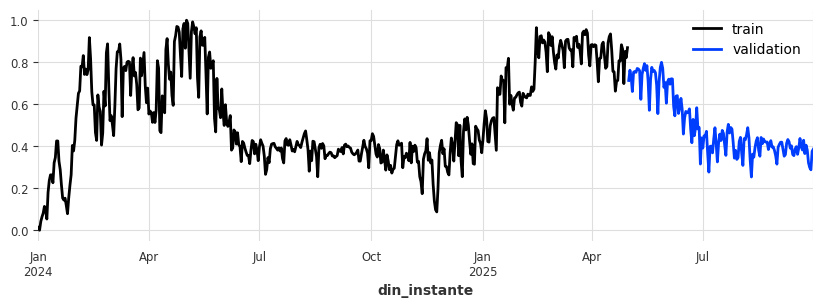

In [6]:
plt.figure(figsize=(10, 3))
train_scaled.plot(label="train")
val_scaled.plot(label="validation")

## Construir modelo

In [8]:
model_name = "TCN_Intercambio_NE_SECO_Diario_2024_2025"
my_model = TCNModel(
    input_chunk_length=56, # 8 semanas
    output_chunk_length=28,  # 4 semanas
    n_epochs=20,
    dropout=0.2,
    dilation_base=2,
    weight_norm=True,
    kernel_size=5,
    num_filters=8,
    nr_epochs_val_period=1,
    random_state=0,
    save_checkpoints=True,
    model_name=model_name,
    force_reset=True,
    **generate_torch_kwargs(),
)

## Treinar Modelo

In [9]:
my_model.fit(
    series=train_scaled,
    past_covariates=day_series,
    val_series=val_scaled,
    val_past_covariates=day_series,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | res_blocks      | ModuleList       | 3.0 K  | train
-------------------------------------------------------------
3.0 K     Trainable params
0         Non-trainable params
3.0 K     Total params
0.012     Total estimated model params size (MB)
41        Modules in train mode
0         Modules in eval mode


Epoch 19: 100%|█████████████████████████████████████████████████| 13/13 [00:01<00:00,  7.84it/s, train_loss=0.0417, val_loss=0.0143]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|█████████████████████████████████████████████████| 13/13 [00:01<00:00,  7.19it/s, train_loss=0.0417, val_loss=0.0143]


TCNModel(output_chunk_shift=0, kernel_size=5, num_filters=8, num_layers=None, dilation_base=2, weight_norm=True, dropout=0.2, input_chunk_length=56, output_chunk_length=28, n_epochs=20, nr_epochs_val_period=1, random_state=0, save_checkpoints=True, model_name=TCN_Intercambio_NE_SECO_Diario_2024_2025, force_reset=True, pl_trainer_kwargs={'accelerator': 'cpu', 'callbacks': [<darts.utils.callbacks.TFMProgressBar object at 0x000002A8FB76F910>]})

## Carregar Modelo

In [10]:
my_model = TCNModel.load_from_checkpoint(model_name=model_name, best=True)

## Backtest

In [11]:
backtest = my_model.historical_forecasts(
    series=ts_scaled,
    past_covariates=day_series,
    start=val_scaled.start_time(),
    forecast_horizon=14, # depois testar com 7
    stride=7, # testando primeiro com 7 depois com 28
    last_points_only=False,
    retrain=False,
    verbose=True,
)
backtest = concatenate(backtest)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

In [ ]:
plt.figure(figsize=(10, 6))
val_scaled.plot(label="actual")
backtest.plot(label="backtest (H=28)")
plt.legend()

In [ ]:
# Previsão para o próximo mês (outubro de 2025)

pred_scaled = my_model.predict(
    n=28,
    series=ts,               # A partir de onde prever (fim do treino+validação)
    past_covariates=day_series # Covariáveis disponíveis (precisa conter os valores para o horizonte de previsão)
)

# Reverter a escala para plotar os valores reais
predicted = scaler.inverse_transform(pred_scaled)


In [ ]:
plt.figure(figsize=(10, 6))
real_scaled.plot(label="real")
predicted.plot(label="predicted (H=28)")
plt.title('Previsão TCN utilizando Covariáveis de Calendário')
plt.legend()